# AI Fake News Detection System

## 01 - Data Analysis & Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to analyze and understand the Fake News and Real News datasets before data preprocessing and model building.

### Tasks Performed

- Load datasets
- Explore dataset structure
- Analyze missing values
- Analyze duplicate values
- Perform statistical analysis
- Visualize data distribution
- Generate insights

In [1]:
# Import required libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Display settings

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Datasets

In [4]:
# Load Fake News dataset
fake_df = pd.read_csv("../data/Fake.csv")

In [5]:
# Load Real News dataset
true_df = pd.read_csv("../data/True.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


## Display first 5 records from Fake News dataset

In [6]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year, President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31, 2017no one likes you Calvin (@calvinstowell) December 31, 2017Your impeachment would make 2018 a great year for America, but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31, 2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31, 2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31, 2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31, 2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all, including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31, 2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s, Easter, Thanksgiving, and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31, 2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31, 2017He s always been like this . . . the only difference is that in the last few years, his filter has been breaking down. Roy Schulze (@thbthttt) December 31, 2017Who, apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31, 2017he s a fucking 5 year old Who Knows (@rainyday80) December 31, 2017So, to all the people who voted for this a hole thinking he would change once he got into power, you were wrong! 70-year-old men don t change and now he s a year older.Photo by Andrew Burton/Getty Images.",News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us, that the Christopher Steele-dossier was what prompted the Russia investigation so he s been lashing out at the Department of Justice and the FBI in order to protect Trump. As it happens, the dossier is not what started the investigation, according to documents obtained by the New York Times.Former Trump campaign adviser George Papadopoulos was drunk in a wine bar when he revealed knowledge of Russian opposition research on Hillary Clinton.On top of that, Papadopoulos wasn t just a covfefe boy for Trump, as his administration has alleged. He had a much larger role, but none so damning as being a drunken fool in a wine bar. Coffee boys don t help to arrange a New York meeting between Trump and President Abdel Fattah el-Sisi of Egypt two months before the election. It was known before th

## Display first 5 records from Real News dataset

In [7]:
true_df.head()

title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

## Dataset Shape Analysis

In [8]:
# Check number of rows and columns

print("Fake News Dataset Shape :", fake_df.shape)
print("Real News Dataset Shape :", true_df.shape)

Fake News Dataset Shape : (23481, 4)
Real News Dataset Shape : (21417, 4)


In [9]:
# Check dataset information

print("Fake News Dataset Information")
fake_df.info()

Fake News Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 60.4 MB


In [10]:
# Check dataset information

print("Real News Dataset Information")
true_df.info()

Real News Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 51.6 MB


## Statistical Summary

In [11]:
# Statistical summary of Fake News dataset

fake_df.describe(include='all')

,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His FBI Director On Day Before Vince Foster Was Found Dead,,News,"May 10, 2017"
freq,6,626,9050,46


In [12]:
# Statistical summary of Real News dataset

true_df.describe(include='all')

,title,text,subject,date
count,21417,21417,21417,21417
unique,20826,21192,2,716
top,Factbox: Trump fills top jobs for his administration,"(Reuters) - Highlights for U.S. President Donald Trump’s administration on Thursday: The United States drops a massive GBU-43 bomb, the largest non-nuclear bomb it has ever used in combat, in Afghanistan against a series of caves used by Islamic State militants, the Pentagon says. Trump says Pyongyang is a problem that “will be taken care of” amid speculation that North Korea is on the verge of a sixth nuclear test. Military force cannot resolve tension over North Korea, China warns, while an influential Chinese newspaper urges Pyongyang to halt its nuclear program in exchange for Beijing’s protection. The Trump administration is focusing its North Korea strategy on tougher economic sanctions, possibly including intercepting cargo ships and punishing Chinese banks doing business with Pyongyang, U.S. officials say. Trump says “things will work out fine” between the United States and Russia, a day after declaring U.S.-Russian relations may be at an all-time low. Trump signals he could be moving closer to the mainstream on monetary policy, saying he has not ruled out reappointment of Janet Yellen as Federal Reserve chair as he considers his choices for the U.S. central bank. [nL1N1HL14B] Trump signs a resolution that will allow U.S. states to restrict how federal funds for contraception and reproductive health are spent, a move cheered by anti-abortion campaigners. Democratic Senator Chris Van Hollen presses Deutsche Bank to release information about issues including Trump’s debt and any bank meetings with Trump administration officials, saying he has “great concern” about possible conflicts of interest. EXPORT-IMPORT BANK Trump’s office says he plans to revive the hobbled Export-Import Bank of the United States, a victory for American manufacturers such as Boeing Co and General Electric Co that have overseas customers that use the agency’s government-backed loans to purchase their products. Top Wall Street bankers say they are having positive discussions about financial regulation in Washington, and downplay the idea U.S. policymakers may force their institutions to split up. The United States is pushing for trade to be a key issue in top-level economic talks with Japan, a source says, an unwelcome development for Tokyo, which is seeking to fend off U.S. pressure to reduce the bilateral trade imbalance. Trump’s administration has focused on one group of illegal immigrants more than others: women with children, according to eight Department of Homeland Security officials interviewed by Reuters about agency planning.",politicsNews,"December 20, 2017"
freq,14,8,11272,182


## Missing Value Analysis

In [13]:
# Check missing values in Fake News dataset

print("Missing Values in Fake News Dataset")
fake_df.isnull().sum()

Missing Values in Fake News Dataset


title      0
text       0
subject    0
date       0
dtype: int64

In [14]:
# Check missing values in Real News dataset

print("Missing Values in Real News Dataset")
true_df.isnull().sum()

Missing Values in Real News Dataset


title      0
text       0
subject    0
date       0
dtype: int64

## Duplicate Value Analysis

In [15]:
# Check duplicate records in Fake News dataset

print("Duplicate Records in Fake News Dataset :", fake_df.duplicated().sum())

Duplicate Records in Fake News Dataset : 3


In [16]:
# Check duplicate records in Real News dataset

print("Duplicate Records in Real News Dataset :", true_df.duplicated().sum())

Duplicate Records in Real News Dataset : 206


## Add Target Labels

In [17]:
# Add target label to Fake News dataset
fake_df["label"] = 0

# Add target label to Real News dataset
true_df["label"] = 1
print("Target labels added successfully.")

Target labels added successfully.


## Merge Both Datasets

In [18]:
# Merge Fake News and Real News datasets

news_df = pd.concat([fake_df, true_df], ignore_index=True)
print("Datasets merged successfully.")

Datasets merged successfully.


In [19]:
# Display first five rows of merged dataset

news_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year, President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31, 2017no one likes you Calvin (@calvinstowell) December 31, 2017Your impeachment would make 2018 a great year for America, but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31, 2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31, 2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31, 2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31, 2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all, including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31, 2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s, Easter, Thanksgiving, and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31, 2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31, 2017He s always been like this . . . the only difference is that in the last few years, his filter has been breaking down. Roy Schulze (@thbthttt) December 31, 2017Who, apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31, 2017he s a fucking 5 year old Who Knows (@rainyday80) December 31, 2017So, to all the people who voted for this a hole thinking he would change once he got into power, you were wrong! 70-year-old men don t change and now he s a year older.Photo by Andrew Burton/Getty Images.",News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us, that the Christopher Steele-dossier was what prompted the Russia investigation so he s been lashing out at the Department of Justice and the FBI in order to protect Trump. As it happens, the dossier is not what started the investigation, according to documents obtained by the New York Times.Former Trump campaign adviser George Papadopoulos was drunk in a wine bar when he revealed knowledge of Russian opposition research on Hillary Clinton.On top of that, Papadopoulos wasn t just a covfefe boy for Trump, as his administration has alleged. He had a much larger role, but none so damning as being a drunken fool in a wine bar. Coffee boys don t help to arrange a New York meeting between Trump and President Abdel Fattah el-Sisi of Egypt two months before the election. It was known b

In [20]:
# Check shape of merged dataset

df = pd.concat([fake_df, true_df], ignore_index=True)

## Dataset Overview

In [21]:
# Display first five records of the merged dataset

df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year, President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31, 2017no one likes you Calvin (@calvinstowell) December 31, 2017Your impeachment would make 2018 a great year for America, but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31, 2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31, 2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31, 2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31, 2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all, including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31, 2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s, Easter, Thanksgiving, and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31, 2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31, 2017He s always been like this . . . the only difference is that in the last few years, his filter has been breaking down. Roy Schulze (@thbthttt) December 31, 2017Who, apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31, 2017he s a fucking 5 year old Who Knows (@rainyday80) December 31, 2017So, to all the people who voted for this a hole thinking he would change once he got into power, you were wrong! 70-year-old men don t change and now he s a year older.Photo by Andrew Burton/Getty Images.",News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us, that the Christopher Steele-dossier was what prompted the Russia investigation so he s been lashing out at the Department of Justice and the FBI in order to protect Trump. As it happens, the dossier is not what started the investigation, according to documents obtained by the New York Times.Former Trump campaign adviser George Papadopoulos was drunk in a wine bar when he revealed knowledge of Russian opposition research on Hillary Clinton.On top of that, Papadopoulos wasn t just a covfefe boy for Trump, as his administration has alleged. He had a much larger role, but none so damning as being a drunken fool in a wine bar. Coffee boys don t help to arrange a New York meeting between Trump and President Abdel Fattah el-Sisi of Egypt two months before the election. It was known b

In [22]:
# Display last five records of the merged dataset

df.tail()

,title,text,subject,date,label
44893,'Fully committed' NATO backs new U.S. approach on Afghanistan,"BRUSSELS (Reuters) - NATO allies on Tuesday welcomed President Donald Trump s decision to commit more forces to Afghanistan, as part of a new U.S. strategy he said would require more troops and funding from America s partners. Having run for the White House last year on a pledge to withdraw swiftly from Afghanistan, Trump reversed course on Monday and promised a stepped-up military campaign against Taliban insurgents, saying: Our troops will fight to win . U.S. officials said he had signed off on plans to send about 4,000 more U.S. troops to add to the roughly 8,400 now deployed in Afghanistan. But his speech did not define benchmarks for successfully ending the war that began with the U.S.-led invasion of Afghanistan in 2001, and which he acknowledged had required an extraordinary sacrifice of blood and treasure . We will ask our NATO allies and global partners to support our new strategy, with additional troops and funding increases in line with our own. We are confident they will, Trump said. That comment signaled he would further increase pressure on U.S. partners who have already been jolted by his repeated demands to step up their contributions to NATO and his description of the alliance as obsolete - even though, since taking office, he has said this is no longer the case. NATO Secretary General Jens Stoltenberg said in a statement: NATO remains fully committed to Afghanistan and I am looking forward to discussing the way ahead with (Defense) Secretary (James) Mattis and our Allies and international partners. NATO has 12,000 troops in Afghanistan, and 15 countries have pledged more, Stoltenberg said. Britain, a leading NATO member, called the U.S. commitment very welcome . In my call with Secretary Mattis yesterday we agreed that despite the challenges, we have to stay the course in Afghanistan to help build up its fragile democracy and reduce the terrorist threat to the West, Defence Secretary Michael Fallon said. Germany, which has borne the brunt of Trump s criticism over the scale of its defense spending, also welcomed the new U.S. plan. Our continued commitment is necessary on the path to stabilizing the country, a government spokeswoman said. In June, European allies had already pledged more troops but had not given details on numbers, waiting for the Trump administration to outline its strategy for the region.Nearly 16 years after the U.S.-led invasion - a response to the Sept. 11 attacks which were planned by al Qaeda leader Osama bin Laden from Afghanistan - the country is still struggling with weak central government and a Taliban insurgency. Trump said he shared the frustration of the American people who were weary of war without victory , but a hasty withdrawal would create a vacuum for groups like Islamic State and al Qaeda to fill.",worldnews,"August 22, 2017",1
44894,LexisNexis withdrew two products from Chinese market,"LONDON (Reuters) - LexisNexis, a provider of legal, regulatory and business information, said on Tuesday it had withdrawn two products from the Chinese market in March this year after it was asked to remove some content. The issue of academic freedom in China hit the headlines this week after the leading British academic publisher, Cambridge University Press, said it had complied with a request to block online access to some scholarly articles in China. It later reversed its position. Earlier this year LexisNexis Business Insight Solutions in China was asked to remove some content from its database, LexisNexis said in a statement. In March 2017, the company withdrew two products (Nexis and LexisNexis Academic) from the Chinese market. LexisNexis is owned by information group Relx.",worldnews,"August 22, 2017",1
44895,Minsk cultural hub becomes haven from authorities,"MINSK (Reuters) - In the shadow of disused Soviet-era factories in Minsk, a street lined with eclectic bars, art galleries and

In [23]:
# Display the shape of the merged dataset

print("Dataset Shape :", df.shape)

Dataset Shape : (44898, 5)


In [24]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB


In [25]:
# Display column names

df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='str')

In [26]:
# Display statistical summary

df.describe(include='all')

,title,text,subject,date,label
count,44898,44898,44898,44898,44898.000000
unique,38729,38646,8,2397,NaN
top,Factbox: Trump fills top jobs for his administration,,politicsNews,"December 20, 2017",NaN
freq,14,627,11272,182,NaN
mean,NaN,NaN,NaN,NaN,0.477015
std,NaN,NaN,NaN,NaN,0.499477
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,1.000000


## Check Missing Values

In [27]:
# Check missing values in the merged dataset

df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

## Check Duplicate Records

In [28]:
# Check duplicate records

df.duplicated().sum()

np.int64(209)

## Display Duplicate Records

In [29]:
# Display duplicate records
duplicate_records = df[df.duplicated()]

duplicate_records.head()

title  \
9942                             HILLARY TWEETS MESSAGE In Defense Of DACA…OOPS! 2014 VIDEO Of Hillary EMERGES Saying Illegal Kids Should Be Sent Back   
11446  FORMER DEMOCRAT WARNS Young Americans: “Rioters are being manipulated by big government forces who need them to regain political power” [VIDEO]   
14925                             [VIDEO] #BlackLivesMatter Terrorists Storm Dartmouth Library, Threaten Students: ‘F*ck You, You Filthy White F*cks!’   
23926                                                                                              Senate tax bill stalls on deficit-focused 'trigger'   
24259                                                                                           Trump warns 'rogue regime' North Korea of grave danger   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [30]:
# Display total duplicate records

print("Total Duplicate Records :", duplicate_records.shape[0])

Total Duplicate Records : 209


## Remove Duplicate Records

In [31]:
# Remove duplicate records

df = df.drop_duplicates()
print("Duplicate records removed successfully.")

Duplicate records removed successfully.


In [32]:
# Verify duplicate records after removal

print("Remaining Duplicate Records :", df.duplicated().sum())

Remaining Duplicate Records : 0


In [33]:
# Check updated dataset shape

print("Updated Dataset Shape :", df.shape)

Updated Dataset Shape : (44689, 5)


## Class Distribution Analysis

In [34]:
# Check class distribution

df["label"].value_counts()

label
0    23478
1    21211
Name: count, dtype: int64

In [35]:
# Count the number of fake and real news articles
class_counts = df["label"].value_counts()

print(f"Fake News Articles : {class_counts[0]}")
print(f"Real News Articles : {class_counts[1]}")

Fake News Articles : 23478
Real News Articles : 21211


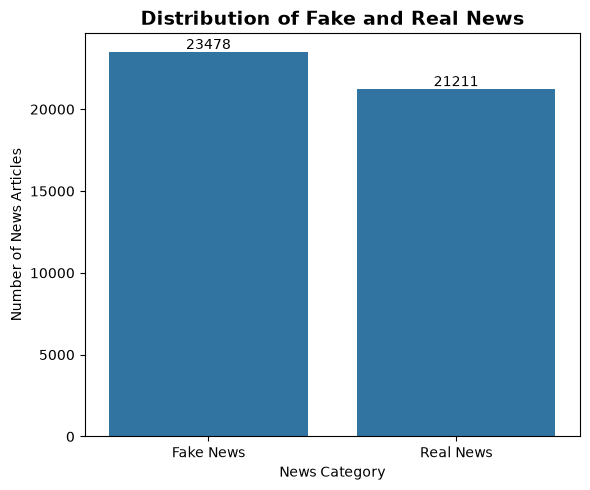

In [36]:
# Visualize class distribution
plt.figure(figsize=(6, 5))

ax = sns.countplot(data=df, x="label")

plt.title("Distribution of Fake and Real News", fontsize=14, fontweight="bold")
plt.xlabel("News Category")
plt.ylabel("Number of News Articles")

plt.xticks([0, 1], ["Fake News", "Real News"])

# Display values on top of bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [37]:
# Display class distribution in percentage

(df["label"].value_counts(normalize=True) * 100).round(2)

label
0    52.54
1    47.46
Name: proportion, dtype: float64

In [38]:
print(df.shape)
print(df["label"].value_counts())

(44689, 5)
label
0    23478
1    21211
Name: count, dtype: int64


## Subject Analysis

In [39]:
# Display unique news subjects

df["subject"].unique()

<ArrowStringArray>
[           'News',        'politics', 'Government News',       'left-news',
         'US_News',     'Middle-east',    'politicsNews',       'worldnews']
Length: 8, dtype: str

In [40]:
# Count the number of news articles in each subject

df["subject"].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

Text(0, 0.5, 'News Subject')

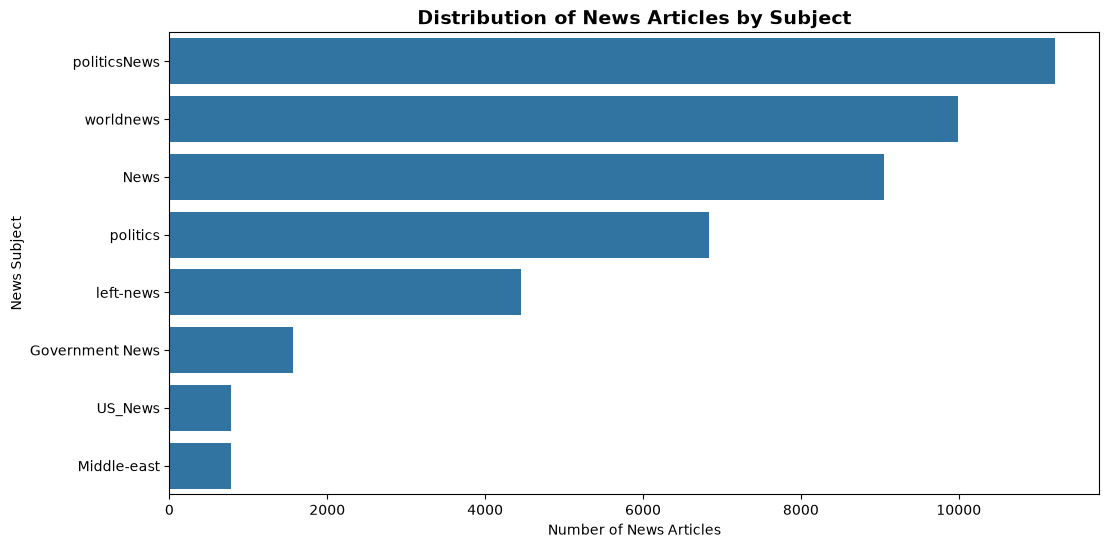

In [41]:
# Visualize the distribution of news subjects
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df,
    y="subject",
    order=df["subject"].value_counts().index
)

plt.title("Distribution of News Articles by Subject", fontsize=14, fontweight="bold")
plt.xlabel("Number of News Articles")
plt.ylabel("News Subject")

In [42]:
# Display values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [43]:
# Display subject distribution in percentage

(df["subject"].value_counts(normalize=True) * 100).round(2)

subject
politicsNews       25.11
worldnews          22.36
News               20.25
politics           15.30
left-news           9.98
Government News     3.51
US_News             1.75
Middle-east         1.74
Name: proportion, dtype: float64

## Date Analysis

In [44]:
# Display first five values from the date column

df["date"].head()

0    December 31, 2017
1    December 31, 2017
2    December 30, 2017
3    December 29, 2017
4    December 25, 2017
Name: date, dtype: str

In [45]:
# Display the number of unique dates

df["date"].nunique()

2397

In [46]:
# Display the top 10 most frequent dates

df["date"].value_counts().head(10)

date
December 6, 2017       166
November 30, 2017      160
November 9, 2017       158
October 13, 2017       153
September 21, 2017     153
September 6, 2017      151
September 7, 2017      148
September 22, 2017     146
October 19, 2017       145
September 12, 2017     143
Name: count, dtype: int64

## Convert Date Column to Datetime Format

In [47]:
# Convert the date column to datetime format

df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Date column converted successfully.")

Date column converted successfully.


In [48]:
# Check the data type of each column

df.dtypes

title                 str
text                  str
subject               str
date       datetime64[us]
label               int64
dtype: object

In [49]:
# Display the earliest and latest news dates

print("Earliest Date :", df["date"].min())
print("Latest Date   :", df["date"].max())

Earliest Date : 2015-05-01 00:00:00
Latest Date   : 2017-12-31 00:00:00


In [50]:
# Extract year from the date column

df["year"] = df["date"].dt.year

df["year"].value_counts().sort_index()

year
2015.0     338
2016.0    7077
2017.0    4453
Name: count, dtype: int64

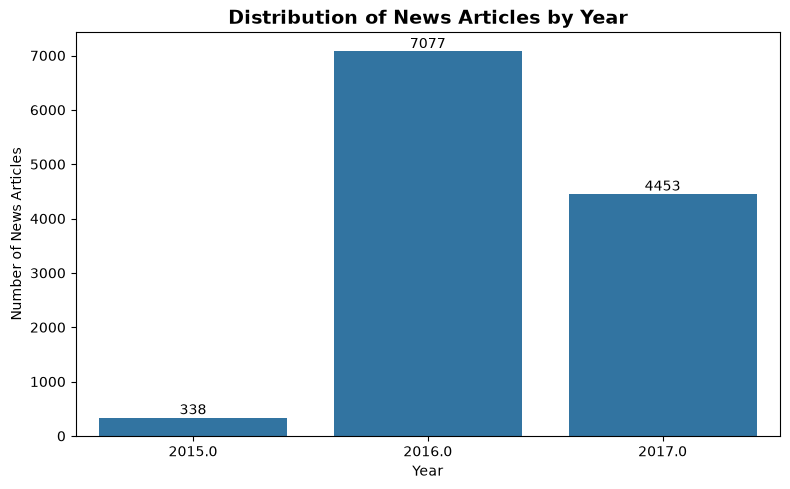

In [51]:
# Visualize news articles by year
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="year",
    order=sorted(df["year"].dropna().unique())
)

plt.title("Distribution of News Articles by Year", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of News Articles")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## Text Length Analysis

In [52]:
# Calculate the number of characters in each news article

df["character_count"] = df["text"].str.len()

df["character_count"].head()

0    2893
1    1898
2    3597
3    2774
4    2346
Name: character_count, dtype: int64

In [53]:
# Display statistical summary of character count

df["character_count"].describe()

count    44689.000000
mean      2467.098682
std       2173.612347
min          1.000000
25%       1232.000000
50%       2185.000000
75%       3101.000000
max      51794.000000
Name: character_count, dtype: float64

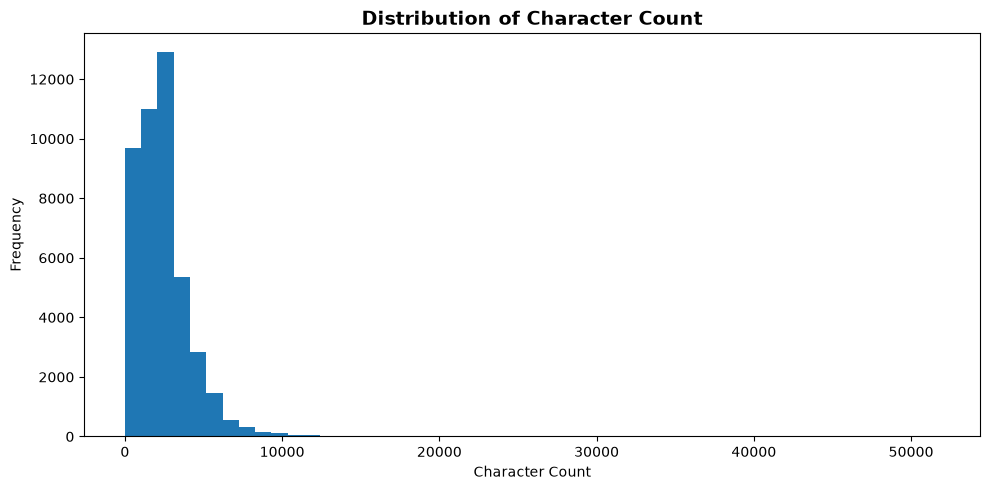

In [54]:
# Visualize character count distribution

plt.figure(figsize=(10,5))

plt.hist(df["character_count"], bins=50)

plt.title("Distribution of Character Count", fontsize=14, fontweight="bold")
plt.xlabel("Character Count")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Word Count Analysis

In [55]:
# Calculate the number of words in each news article

df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

df["word_count"].head()

0    495
1    305
2    580
3    444
4    420
Name: word_count, dtype: int64

In [56]:
# Display statistical summary of word count

df["word_count"].describe()

count    44689.000000
mean       404.966502
std        351.573770
min          0.000000
25%        203.000000
50%        362.000000
75%        512.000000
max       8135.000000
Name: word_count, dtype: float64

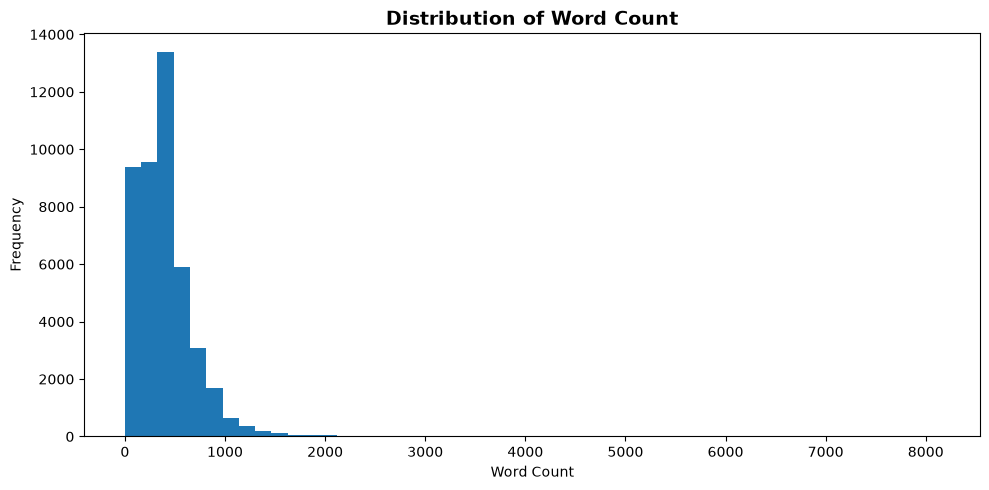

In [57]:
# Visualize word count distribution
plt.figure(figsize=(10,5))

plt.hist(df["word_count"], bins=50)

plt.title("Distribution of Word Count", fontsize=14, fontweight="bold")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Most Frequent Words Analysis

In [58]:
# Import Counter for word frequency analysis

from collections import Counter

In [59]:
# Combine all news articles into a single text

all_text = " ".join(df["text"].astype(str))

In [60]:
# Split text into individual words

words = all_text.split()

print("Total Words :", len(words))

Total Words : 18097548


In [61]:
# Count the frequency of each word

word_frequency = Counter(words)

word_frequency.most_common(20)

[('the', 900705),
 ('to', 526884),
 ('of', 435113),
 ('and', 390333),
 ('a', 387801),
 ('in', 320277),
 ('that', 219966),
 ('on', 180437),
 ('s', 171421),
 ('for', 165362),
 ('is', 159361),
 ('was', 113548),
 ('with', 113071),
 ('he', 105129),
 ('Trump', 100870),
 ('as', 96141),
 ('The', 94481),
 ('said', 92268),
 ('by', 92156),
 ('his', 91627)]

In [62]:
# Create a DataFrame of the top 20 most frequent words

top_words = pd.DataFrame(
    word_frequency.most_common(20),
    columns=["Word", "Frequency"]
)

top_words

,Word,Frequency
0,the,900705
1,to,526884
2,of,435113
3,and,390333
4,a,387801
5,in,320277
6,that,219966
7,on,180437
8,s,171421
9,for,165362


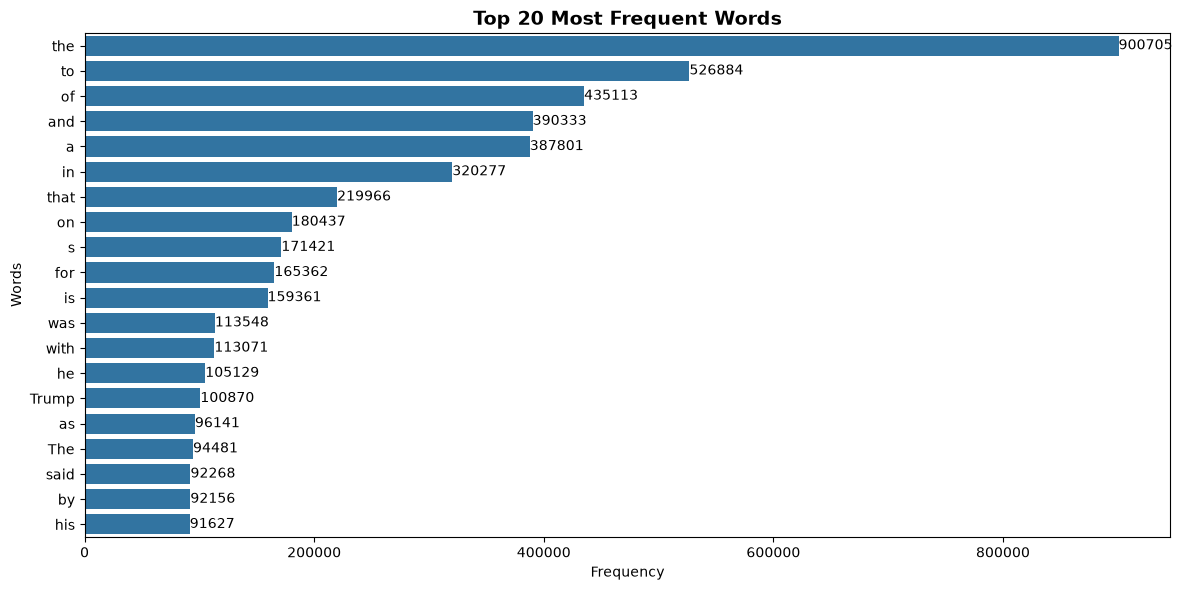

In [63]:
# Visualize the top 20 most frequent words

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_words,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Most Frequent Words", fontsize=14, fontweight="bold")
plt.xlabel("Frequency")
plt.ylabel("Words")

# Display values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## Title Length Analysis

In [64]:
# Calculate the number of words in each news title

df["title_word_count"] = df["title"].apply(lambda x: len(str(x).split()))

df["title_word_count"].head()

0    12
1     8
2    15
3    14
4    11
Name: title_word_count, dtype: int64

In [65]:
# Display statistical summary of title word count

df["title_word_count"].describe()

count    44689.000000
mean        12.463246
std          4.116191
min          1.000000
25%         10.000000
50%         11.000000
75%         14.000000
max         42.000000
Name: title_word_count, dtype: float64

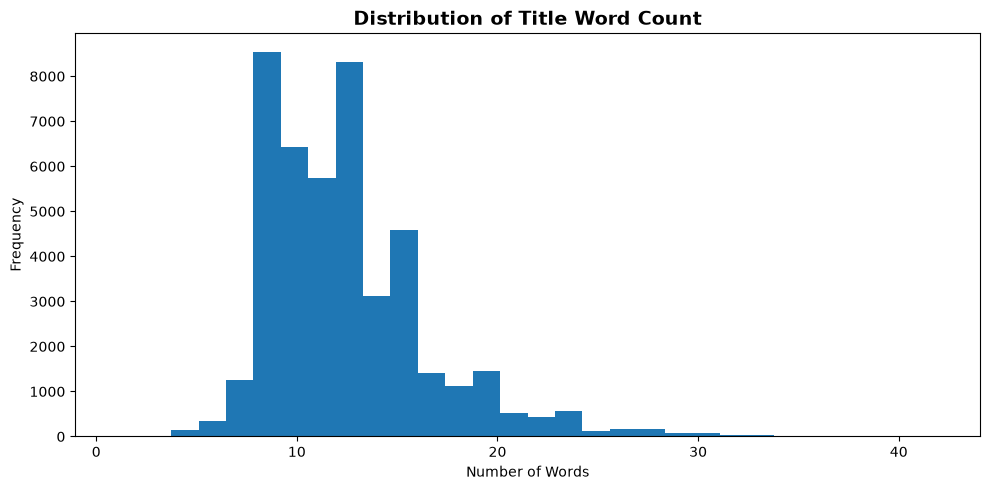

In [66]:
# Visualize title word count distribution

plt.figure(figsize=(10,5))

plt.hist(df["title_word_count"], bins=30)

plt.title("Distribution of Title Word Count", fontsize=14, fontweight="bold")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Average Text Statistics by News Category

In [67]:
# Compare average text statistics for Fake and Real News

df.groupby("label")[["word_count", "character_count", "title_word_count"]].mean().round(2)

,word_count,character_count,title_word_count
label,,,
0,423.22,2547.56,14.73
1,384.76,2378.04,9.95


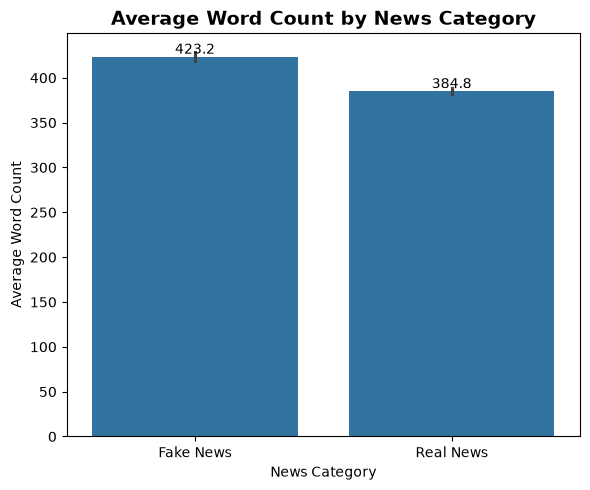

In [68]:
# Visualize average word count by news category
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=df,
    x="label",
    y="word_count",
    estimator="mean"
)

plt.title("Average Word Count by News Category", fontsize=14, fontweight="bold")
plt.xlabel("News Category")
plt.ylabel("Average Word Count")

plt.xticks([0,1], ["Fake News", "Real News"])

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

## Exploratory Data Analysis Summary

### Key Observations

- The dataset contains both Fake News and Real News articles.
- The dataset is nearly balanced, making it suitable for classification tasks.
- No missing values were found in the dataset.
- Duplicate records were identified and removed successfully.
- Politics-related news articles are the most common category.
- Most news articles belong to the years 2016 and 2017.
- News articles vary significantly in character count and word count.
- Frequent words in the raw dataset include common English words, which will be handled during preprocessing.
- The dataset is clean and ready for NLP preprocessing and machine learning.